In [1]:
import os 
import tensorflow as tf
import keras
from keras.applications.vgg16 import VGG16,preprocess_input,decode_predictions
from keras.preprocessing.image import load_img, img_to_array
import shutil
import math
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def create_validation_set(directory = "training_set", percentage = 10,val_dir = "validation_set"):
    """
    Creates a validation set by moving the last P% of files from the given directory
    into a subdirectory named 'validation_set'.

    Parameters:
    directory (str): Path to the directory containing the files.
    percentage (float): Percentage (0-100) of files to move.
    """

    # Ensure directory exists
    if not os.path.isdir(directory):
        raise ValueError(f"Directory '{directory}' does not exist.")

    # Get all files in directory (ignore subfolders)
    files = [f for f in os.listdir(directory) 
             if os.path.isfile(os.path.join(directory, f))]

    if not files:
        print("No files found in the directory.")
        return

    # Sort files so "last P%" is deterministic
    files.sort()

    # Number of files to move
    count_to_move = math.ceil(len(files) * (percentage / 100))

    # Select last P%
    files_to_move = files[-count_to_move:]

    # Create validation_set directory
    os.makedirs(val_dir, exist_ok=True)

    # Move files
    for filename in files_to_move:
        src = os.path.join(directory, filename)
        dst = os.path.join(val_dir, filename)
        shutil.move(src, dst)

    print(f"Moved {len(files_to_move)} files to {val_dir}.")


In [7]:
create_validation_set("./training_set/dogs",val_dir="./validation_set/dogs",percentage=20)
create_validation_set("./training_set/cats",val_dir="./validation_set/cats",percentage=20)


Moved 802 files to ./validation_set/dogs.
Moved 801 files to ./validation_set/cats.


# Predict using Pre-Trained Model


In [2]:
img_path = "training_set/cats/cat.1.jpg"
img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array,axis=0)
img_array_preprocessed = preprocess_input(img_array)

In [3]:
pretrained_model = VGG16(weights="imagenet")

I0000 00:00:1763327485.599381   20723 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2113 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 851s 2us/step


In [6]:
preds = pretrained_model.predict(img_array_preprocessed)
top_preds = decode_predictions(preds, top=10)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [7]:
print("TOP 10 Predictions: ")
for i,(imgnet_id, label, prob) in enumerate(top_preds):
    print(f"{i+1}. {label:20s} ({prob*100:.2f})")

TOP 10 Predictions: 
1. tabby                (49.12)
2. tiger_cat            (35.41)
3. Egyptian_cat         (7.32)
4. space_heater         (0.49)
5. radiator             (0.45)
6. doormat              (0.43)
7. lynx                 (0.39)
8. carton               (0.31)
9. bucket               (0.25)
10. bookcase             (0.20)


High uncertainity

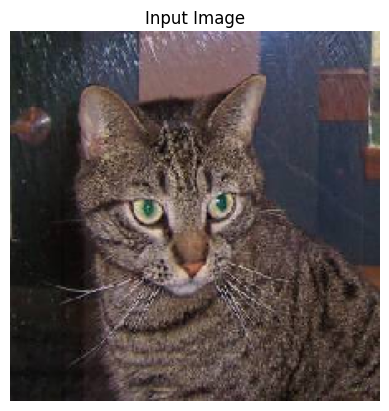

In [8]:
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Transfer Learning VGG16

In [7]:
from keras.models import Sequential
from keras import layers
from keras.layers import GlobalAveragePooling2D, Dense


In [3]:
IMG_WIDTH, IMG_HEIGHT = 224,224
BATCH_SIZE = 32

In [4]:
TRAINING_SET_DIR = "training_set"
VALIDATION_SET_DIR = "validation_set"
TEST_SET_DIR = "test_set"

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

I0000 00:00:1763494823.141878    6471 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2111 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


In [20]:
train_set = keras.utils.image_dataset_from_directory(TRAINING_SET_DIR,
                                                     image_size=(IMG_WIDTH,IMG_HEIGHT),
                                                     batch_size=BATCH_SIZE,
                                                     shuffle=True
                                                     )


Found 6402 files belonging to 2 classes.


In [10]:
val_set = keras.utils.image_dataset_from_directory(VALIDATION_SET_DIR,
                                                     image_size=(IMG_WIDTH,IMG_HEIGHT),
                                                     batch_size=BATCH_SIZE,
                                                     shuffle=False
                                                     )

Found 1603 files belonging to 2 classes.


In [24]:
test_set = keras.utils.image_dataset_from_directory(TEST_SET_DIR,
                                                    image_size=(IMG_WIDTH,IMG_HEIGHT),
                                                    batch_size=BATCH_SIZE,
                                                    )

Found 2023 files belonging to 2 classes.


In [15]:
class_names = train_set.class_names
class_names

['cats', 'dogs']

### View a Trainset Batch Sample

Dataset loaded!
Number of batches: 201
Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Label values: [1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 0 0]


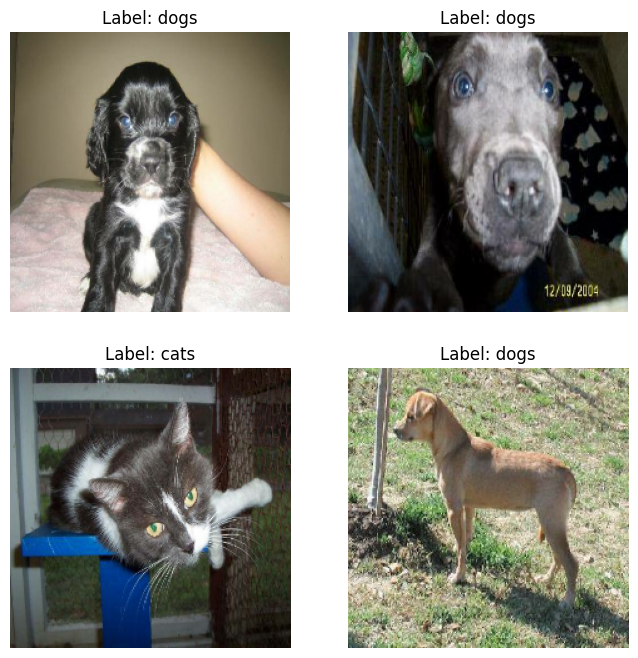

In [21]:
train_ds = train_set
# -------------------------------
# 2. Print basic info
# -------------------------------
print("Dataset loaded!")
print("Number of batches:", len(train_ds))

# Print the shapes of the first batch
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Label values:", labels.numpy())

# -------------------------------
# 3. Display sample images
# -------------------------------
plt.figure(figsize=(8, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Label: {class_names[labels[i]]}")
    plt.axis("off")

plt.show()

In [23]:
train_set = train_set.map(lambda x,y: (data_augmentation(x),y))
train_set = train_set.map(lambda x, y: (preprocess_input(x), y))

In [25]:
val_set = val_set.map(lambda x, y: (preprocess_input(x), y))

## Load pretrained model

In [26]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH,IMG_HEIGHT,3))
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

## Freeze all layers

In [27]:
for layer in base_model.layers:
    layer.trainable = False

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Add Model trainable layers

In [28]:
new_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,585 (56.26 MB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Tune model

In [29]:
new_model.compile(optimizer=keras.optimizers.Adam(0.001), 
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                  )

In [ ]:
new_model.fit(train_set,
              epochs=5,
              validation_data=val_set
              )